In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your data folder
DATA_FOLDER = r"C:\Users\NARKEES SALEEM\tourism_project\data"

print("Ready to load files from:", DATA_FOLDER)

Ready to load files from: C:\Users\NARKEES SALEEM\tourism_project\data


In [2]:
df_trans = pd.read_excel(f"{DATA_FOLDER}/Transaction.xlsx")
df_user  = pd.read_excel(f"{DATA_FOLDER}/User.xlsx")
df_item  = pd.read_excel(f"{DATA_FOLDER}/Item.xlsx")          # or use Updated_Item.xlsx if better
df_type  = pd.read_excel(f"{DATA_FOLDER}/Type.xlsx")
df_mode  = pd.read_excel(f"{DATA_FOLDER}/Mode.xlsx")
df_city  = pd.read_excel(f"{DATA_FOLDER}/City.xlsx")

print("Loaded successfully!")
print(f"Transactions: {len(df_trans):,} rows")
print(f"Users:        {len(df_user):,} rows")
print(f"Attractions:  {len(df_item):,} rows")

Loaded successfully!
Transactions: 52,930 rows
Users:        33,530 rows
Attractions:  30 rows


In [4]:
print("Transaction columns:")
print(df_trans.columns.tolist())

print("\nUser columns:")
print(df_user.columns.tolist())

print("\nItem columns:")
print(df_item.columns.tolist())

print("\nVisit Mode lookup:")
print(df_mode)

Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

User columns:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Item columns:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Visit Mode lookup:
   VisitModeId VisitMode
0            0         -
1            1  Business
2            2   Couples
3            3    Family
4            4   Friends
5            5      Solo


In [5]:
print("Missing values in Transaction:")
print(df_trans.isnull().sum())

Missing values in Transaction:
TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
dtype: int64


In [6]:
# Fill missing ratings with average (you can change this later)
if 'Rating' in df_trans.columns and df_trans['Rating'].isnull().any():
    avg = df_trans['Rating'].mean()
    df_trans['Rating'] = df_trans['Rating'].fillna(avg)
    print(f"Filled missing ratings with average: {avg:.2f}")
else:
    print("No missing ratings or Rating column not found")

No missing ratings or Rating column not found


In [8]:
master = df_trans.merge(df_user, on='UserId', how='left') \
                 .merge(df_item, on='AttractionId', how='left') \
                 .merge(df_type, on='AttractionTypeId', how='left') \
                 .merge(df_mode, left_on='VisitMode', right_on='VisitModeId', how='left')

print("Master table created!")
print("Rows:", len(master))
print("Columns:", master.columns.tolist())

Master table created!
Rows: 52930
Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode_x', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'VisitModeId', 'VisitMode_y']


Saved cleaned_master.csv

Top 10 attractions by avg rating:
 Attraction
Mount Semeru Volcano                  4.698795
Waterbom Bali                         4.646601
Bromo Tengger Semeru National Park    4.611549
Khayangan Reflexology & Massage       4.571429
Jomblang Cave                         4.503704
Jodipan Colorful Village              4.318182
Nusa Dua Beach                        4.275665
Sacred Monkey Forest Sanctuary        4.267086
Ullen Sentalu Museum                  4.256646
Uluwatu Temple                        4.219411
Name: Rating, dtype: float64


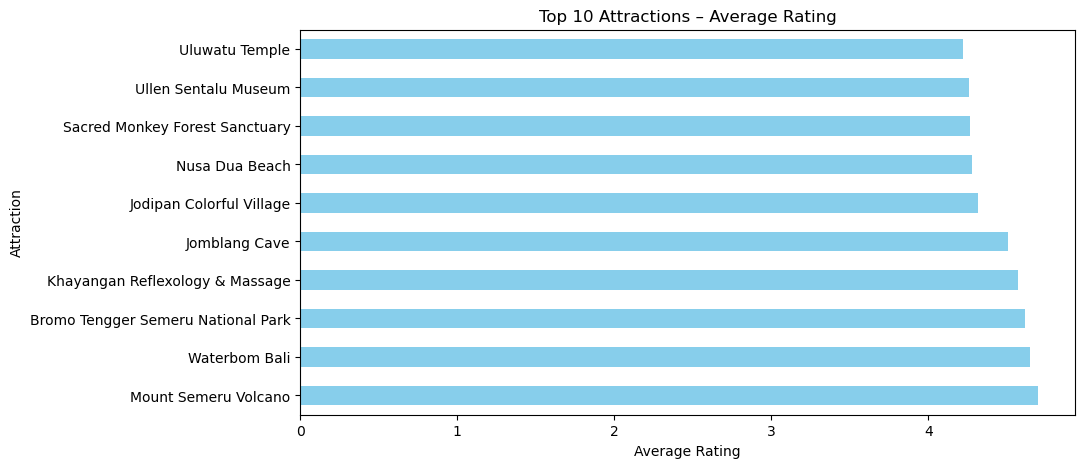

In [9]:
master.to_csv("cleaned_master.csv", index=False)
print("Saved cleaned_master.csv")

# Top 10 attractions by average rating
top_attr = master.groupby('Attraction')['Rating'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 attractions by avg rating:\n", top_attr)

# Simple bar plot
top_attr.plot(kind='barh', figsize=(10,5), color='skyblue')
plt.title('Top 10 Attractions – Average Rating')
plt.xlabel('Average Rating')
plt.show()

In [11]:
visit_mode_stats = master.groupby('VisitMode_y').agg({
    'Rating': ['mean', 'count'],
    'UserId': 'nunique'
}).round(2)

visit_mode_stats.columns = ['AvgRating', 'VisitCount', 'UniqueUsers']
print("Visit Mode Summary:")
display(visit_mode_stats.sort_values('VisitCount', ascending=False))

Visit Mode Summary:


,AvgRating,VisitCount,UniqueUsers
VisitMode_y,,,
Couples,4.12,21620,14972
Family,4.22,15217,10810
Friends,4.17,10945,7783
Solo,4.09,4525,3189
Business,4.31,623,478


In [13]:
print("All columns in master right now:")
print(master.columns.tolist())

All columns in master right now:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode_x', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'VisitModeId', 'VisitMode_y']


In [14]:
print("Columns containing 'Visit' or 'Mode':")
print([col for col in master.columns if 'visit' in col.lower() or 'mode' in col.lower()])

print("\nFirst 8 rows of those columns (if any exist):")
mode_cols = [col for col in master.columns if 'visit' in col.lower() or 'mode' in col.lower()]
if mode_cols:
    display(master[mode_cols].head(8))
else:
    print("No columns with 'visit' or 'mode' found")

Columns containing 'Visit' or 'Mode':
['VisitYear', 'VisitMonth', 'VisitMode_x', 'VisitModeId', 'VisitMode_y']

First 8 rows of those columns (if any exist):


,VisitYear,VisitMonth,VisitMode_x,VisitModeId,VisitMode_y
0,2022,10,2,2,Couples
1,2022,10,4,4,Friends
2,2022,10,3,3,Family
3,2022,10,3,3,Family
4,2022,10,2,2,Couples
5,2022,10,4,4,Friends
6,2022,9,2,2,Couples
7,2022,10,4,4,Friends


In [15]:
if 'VisitYearMonth' in master.columns:
    print("VisitYearMonth exists. Sample values:")
    print(master['VisitYearMonth'].head(10).unique())
else:
    print("VisitYearMonth does NOT exist yet. You need to run the feature engineering cell first.")

VisitYearMonth does NOT exist yet. You need to run the feature engineering cell first.


In [16]:
# Safe display – only columns that actually exist
safe_cols = ['UserId', 'Attraction', 'Rating', 'AttractionType']
safe_cols = [c for c in safe_cols if c in master.columns]

print("Safe columns that exist:", safe_cols)
display(master[safe_cols].head(10))

Safe columns that exist: ['UserId', 'Attraction', 'Rating', 'AttractionType']


,UserId,Attraction,Rating,AttractionType
0,70456,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas
1,7567,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas
2,79069,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas
3,31019,Sacred Monkey Forest Sanctuary,3,Nature & Wildlife Areas
4,43611,Sacred Monkey Forest Sanctuary,3,Nature & Wildlife Areas
5,43471,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas
6,76492,Sacred Monkey Forest Sanctuary,4,Nature & Wildlife Areas
7,20977,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas
8,18655,Sacred Monkey Forest Sanctuary,3,Nature & Wildlife Areas
9,62907,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas


In [17]:
# Rename for easier use in EDA and modeling
master = master.rename(columns={
    'VisitMode_x': 'VisitModeId_Num',     # the numeric foreign key
    'VisitMode_y': 'VisitMode_Name',      # the readable name we want
})

print("Renamed columns. New list:")
print(master.columns.tolist())

# Quick check — should show categories like Family, Business, etc.
print("\nTop visit modes:")
print(master['VisitMode_Name'].value_counts(dropna=False).head(10))

Renamed columns. New list:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId_Num', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'VisitModeId', 'VisitMode_Name']

Top visit modes:
VisitMode_Name
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64


In [18]:
# Create combined year-month for time-based analysis
master['VisitYearMonth'] = (
    master['VisitYear'].astype(str) + '-' + 
    master['VisitMonth'].astype(str).str.zfill(2)
)

print("VisitYearMonth created. Sample values:")
print(master['VisitYearMonth'].value_counts().sort_index().head(12))

VisitYearMonth created. Sample values:
VisitYearMonth
2013-01    207
2013-02    186
2013-03    238
2013-04    222
2013-05    242
2013-06    257
2013-07    316
2013-08    281
2013-09    271
2013-10    261
2013-11    214
2013-12    288
Name: count, dtype: int64


In [19]:
# Safe sample display – using columns that definitely exist now
display_cols = ['UserId', 'Attraction', 'Rating', 'AttractionType', 
                'VisitMode_Name', 'VisitYearMonth']

# Filter only columns that are actually present
available_cols = [c for c in display_cols if c in master.columns]

print("Displaying sample with available columns:", available_cols)
display(master[available_cols].head(12))

# Bonus: show a few with different visit modes
print("\nOne example per visit mode (if exists):")
display(master.drop_duplicates(subset='VisitMode_Name')[available_cols].head(8))

Displaying sample with available columns: ['UserId', 'Attraction', 'Rating', 'AttractionType', 'VisitMode_Name', 'VisitYearMonth']


,UserId,Attraction,Rating,AttractionType,VisitMode_Name,VisitYearMonth
0,70456,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Couples,2022-10
1,7567,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Friends,2022-10
2,79069,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Family,2022-10
3,31019,Sacred Monkey Forest Sanctuary,3,Nature & Wildlife Areas,Family,2022-10
4,43611,Sacred Monkey Forest Sanctuary,3,Nature & Wildlife Areas,Couples,2022-10
5,43471,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Friends,2022-10
6,76492,Sacred Monkey Forest Sanctuary,4,Nature & Wildlife Areas,Couples,2022-09
7,20977,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Friends,2022-10
8,18655,Sacred Monkey Forest Sanctuary,3,Nature & Wildlife Areas,Couples,2022-09
9,62907,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Couples,2022-09



One example per visit mode (if exists):


,UserId,Attraction,Rating,AttractionType,VisitMode_Name,VisitYearMonth
0,70456,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Couples,2022-10
1,7567,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Friends,2022-10
2,79069,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Family,2022-10
19,33716,Sacred Monkey Forest Sanctuary,5,Nature & Wildlife Areas,Solo,2022-07
1655,18411,Sacred Monkey Forest Sanctuary,4,Nature & Wildlife Areas,Business,2017-05


In [20]:
# Visit mode summary – using the renamed column
visit_mode_stats = master.groupby('VisitMode_Name').agg({
    'Rating': ['mean', 'count', 'std'],
    'UserId': 'nunique'
}).round(2)

visit_mode_stats.columns = ['AvgRating', 'VisitCount', 'RatingStd', 'UniqueUsers']
print("Visit Mode Summary (sorted by popularity):")
display(visit_mode_stats.sort_values('VisitCount', ascending=False))

Visit Mode Summary (sorted by popularity):


,AvgRating,VisitCount,RatingStd,UniqueUsers
VisitMode_Name,,,,
Couples,4.12,21620,1.00,14972
Family,4.22,15217,0.94,10810
Friends,4.17,10945,0.94,7783
Solo,4.09,4525,0.99,3189
Business,4.31,623,0.85,478


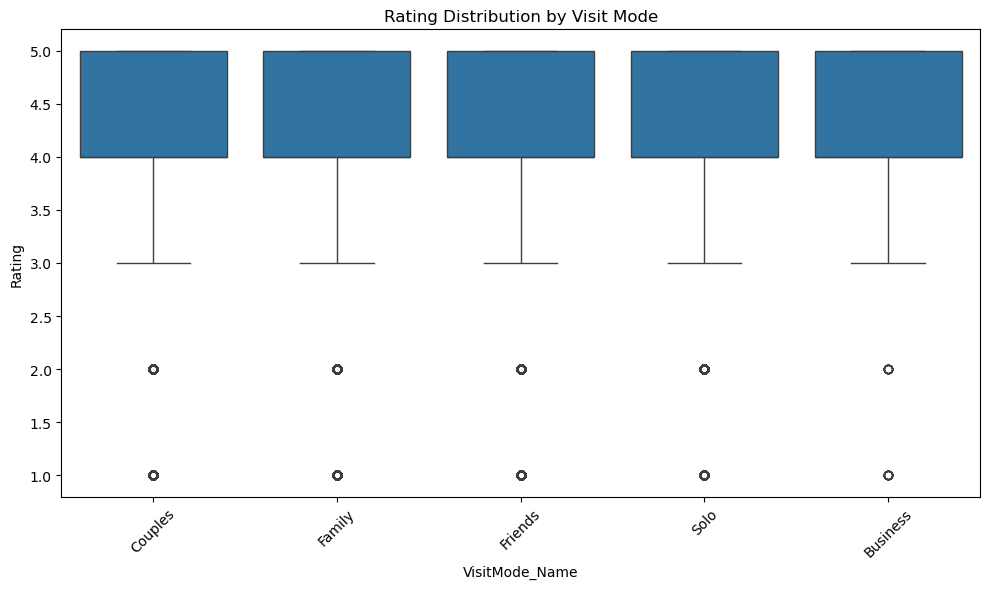

In [21]:
# Plot 1: Ratings by visit mode
plt.figure(figsize=(10,6))
sns.boxplot(data=master, x='VisitMode_Name', y='Rating', order=master['VisitMode_Name'].value_counts().index)
plt.title('Rating Distribution by Visit Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_ratings_by_mode.png', dpi=150)
plt.show()

In [22]:
master.to_parquet("master_ready_for_eda_models.parquet", index=False)
print("Saved improved version with renamed columns")

Saved improved version with renamed columns


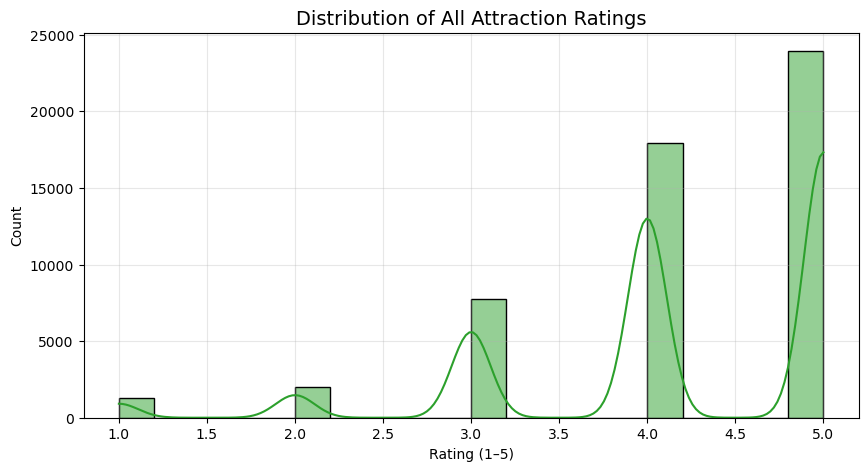

In [23]:
# EDA 1 – Overall rating distribution
plt.figure(figsize=(10, 5))
sns.histplot(master['Rating'], bins=20, kde=True, color='#2ca02c')
plt.title('Distribution of All Attraction Ratings', fontsize=14)
plt.xlabel('Rating (1–5)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.savefig('eda_01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

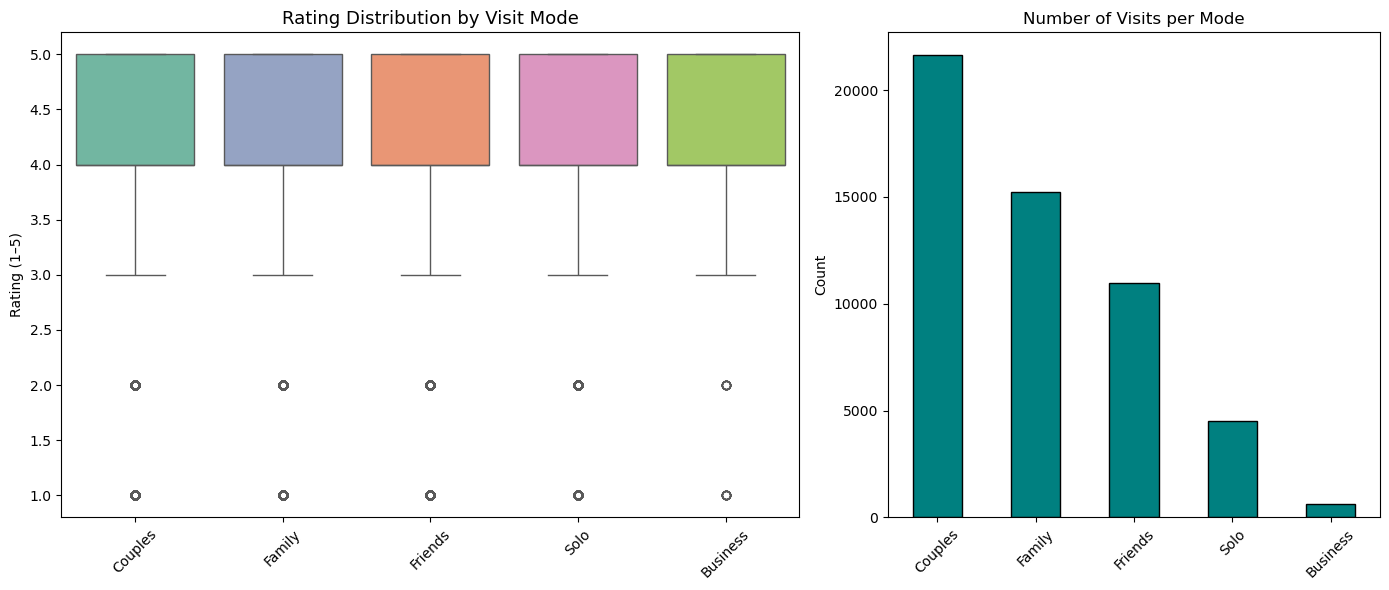

In [29]:
# EDA 2 – Ratings by Visit Mode (no warnings, clean style)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 2]})

# Boxplot with hue = x (recommended way)
sns.boxplot(
    data=master,
    x='VisitMode_Name',
    y='Rating',
    hue='VisitMode_Name',          # ← fixes palette warning
    order=master['VisitMode_Name'].value_counts().index,
    palette='Set2',
    dodge=False,                   # keeps boxes centered
    legend=False,                  # hides duplicate legend
    ax=ax1
)
ax1.set_title('Rating Distribution by Visit Mode', fontsize=13)
ax1.set_xlabel('')
ax1.set_ylabel('Rating (1–5)')
ax1.tick_params(axis='x', rotation=45)

# Barplot – count of visits per mode
master['VisitMode_Name'].value_counts().plot(
    kind='bar',
    ax=ax2,
    color='teal',
    edgecolor='black'
)
ax2.set_title('Number of Visits per Mode')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_02_ratings_by_visit_mode_clean.png', dpi=150, bbox_inches='tight')
plt.show()



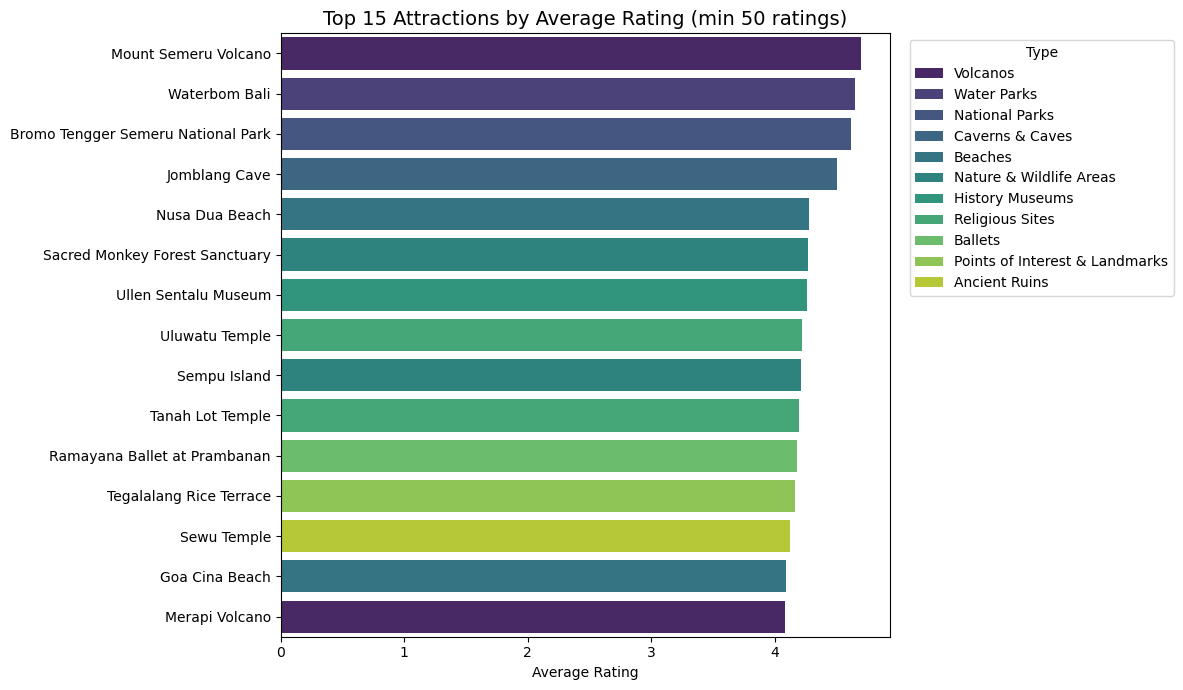

In [25]:
# EDA 3 – Top 15 attractions by average rating (with minimum support filter)
attr_stats = master.groupby(['Attraction', 'AttractionType']).agg({
    'Rating': ['mean', 'count']
}).reset_index()
attr_stats.columns = ['Attraction', 'AttractionType', 'AvgRating', 'Count']

top_rated = attr_stats[attr_stats['Count'] >= 50].sort_values('AvgRating', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_rated, x='AvgRating', y='Attraction', hue='AttractionType', dodge=False, palette='viridis')
plt.title('Top 15 Attractions by Average Rating (min 50 ratings)', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('')
plt.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_03_top_rated_attractions.png', dpi=150, bbox_inches='tight')
plt.show()

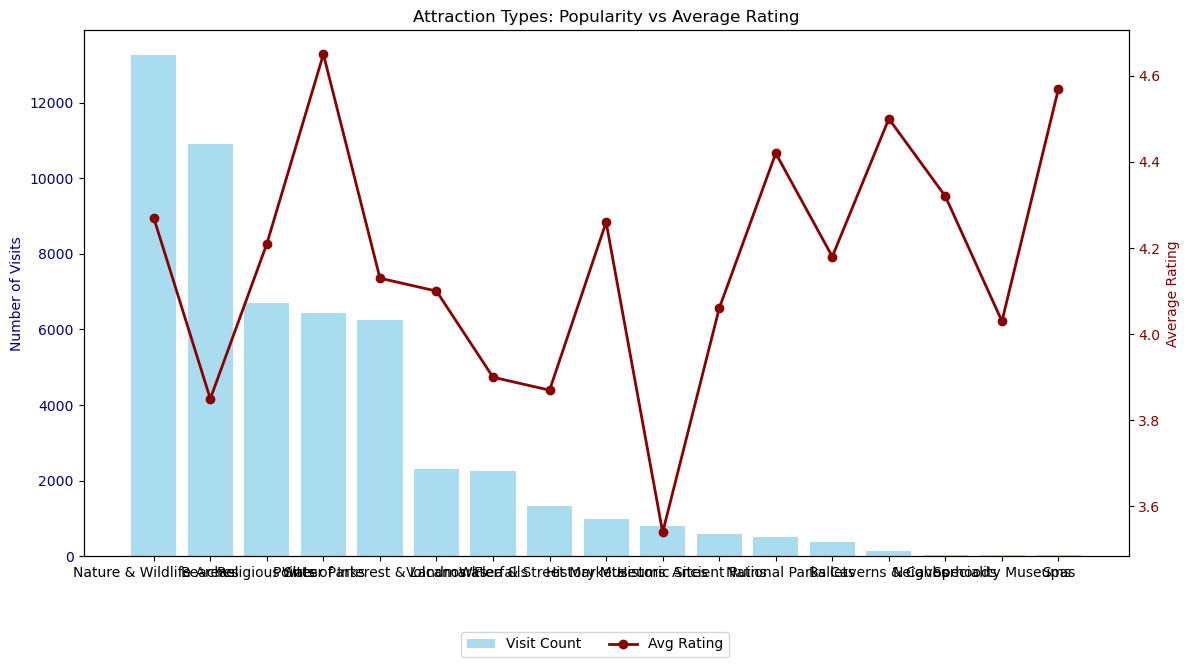

In [30]:
# EDA 4 – Attraction types – popularity & average rating
type_stats = master.groupby('AttractionType').agg({
    'Rating': ['mean', 'count']
}).round(2)
type_stats.columns = ['AvgRating', 'VisitCount']
type_stats = type_stats.sort_values('VisitCount', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(type_stats.index, type_stats['VisitCount'], color='skyblue', alpha=0.7, label='Visit Count')
ax1.set_ylabel('Number of Visits', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

ax2 = ax1.twinx()
ax2.plot(type_stats.index, type_stats['AvgRating'], color='darkred', marker='o', linewidth=2, label='Avg Rating')
ax2.set_ylabel('Average Rating', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Attraction Types: Popularity vs Average Rating')
plt.xticks(rotation=45, ha='right')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.savefig('eda_04_attraction_types_popularity_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Reload lookup tables (run this once after kernel restart or if variables lost)
import pandas as pd

DATA_FOLDER = r"C:\Users\NARKEES SALEEM\tourism_project\data"  # ← use your actual path

df_continent = pd.read_excel(f"{DATA_FOLDER}/Continent.xlsx")
df_region    = pd.read_excel(f"{DATA_FOLDER}/Region.xlsx")
df_country   = pd.read_excel(f"{DATA_FOLDER}/Country.xlsx")
df_city      = pd.read_excel(f"{DATA_FOLDER}/City.xlsx")

print("Lookup tables reloaded:")
print("Continent shape:", df_continent.shape)
print("Country shape:  ", df_country.shape)
print("City shape:     ", df_city.shape)
print("\nContinent columns:", df_continent.columns.tolist())
print("Country columns: ", df_country.columns.tolist())
print("City columns:    ", df_city.columns.tolist())

Lookup tables reloaded:
Continent shape: (6, 2)
Country shape:   (165, 3)
City shape:      (9143, 3)

Continent columns: ['ContinentId', 'Continent']
Country columns:  ['CountryId', 'Country', 'RegionId']
City columns:     ['CityId', 'CityName', 'CountryId']


In [49]:
# Merge Continent name
master = master.merge(df_continent, on='ContinentId', how='left')
print("Added Continent. Sample:")
display(master[['ContinentId', 'Continent']].drop_duplicates().head(8))

Added Continent. Sample:


,ContinentId,Continent
0,5,Europe
1,2,America
6,1,Africa
11,4,Australia & Oceania
19,3,Asia


In [50]:
# Merge Country name
master = master.merge(df_country, on='CountryId', how='left')
print("Added Country. Sample:")
display(master[['CountryId', 'Country']].drop_duplicates().head(8))

Added Country. Sample:


,CountryId,Country
0,163,United Kingdom
1,48,Canada
2,54,Brazil
3,135,Switzerland
5,51,United States
6,9,Tanzania
8,22,South Africa
11,109,Australia


In [51]:
# Merge User City name
master = master.merge(
    df_city.rename(columns={'CityName': 'UserCityName'}),
    on='CityId', how='left'
)
print("Added User City. Sample:")
display(master[['CityId', 'UserCityName']].drop_duplicates().head(8))

Added User City. Sample:


,CityId,UserCityName
0,4341.0,Guildford
1,464.0,Ontario
2,774.0,Brazil
3,583.0,Zurich
4,1396.0,Manchester
5,1806.0,San Francisco
6,31.0,Arusha
7,8258.0,Edinburgh


In [52]:
# Merge Attraction City name (optional but recommended)
master = master.merge(
    df_city.rename(columns={'CityName': 'AttractionCityName'}),
    left_on='AttractionCityId', right_on='CityId', how='left',
    suffixes=('', '_attr')
)
print("Added Attraction City. Sample:")
display(master[['AttractionCityId', 'AttractionCityName']].drop_duplicates().head(8))

Added Attraction City. Sample:


,AttractionCityId,AttractionCityName
0,1,Douala
45170,2,South Region
45999,3,N'Djamena


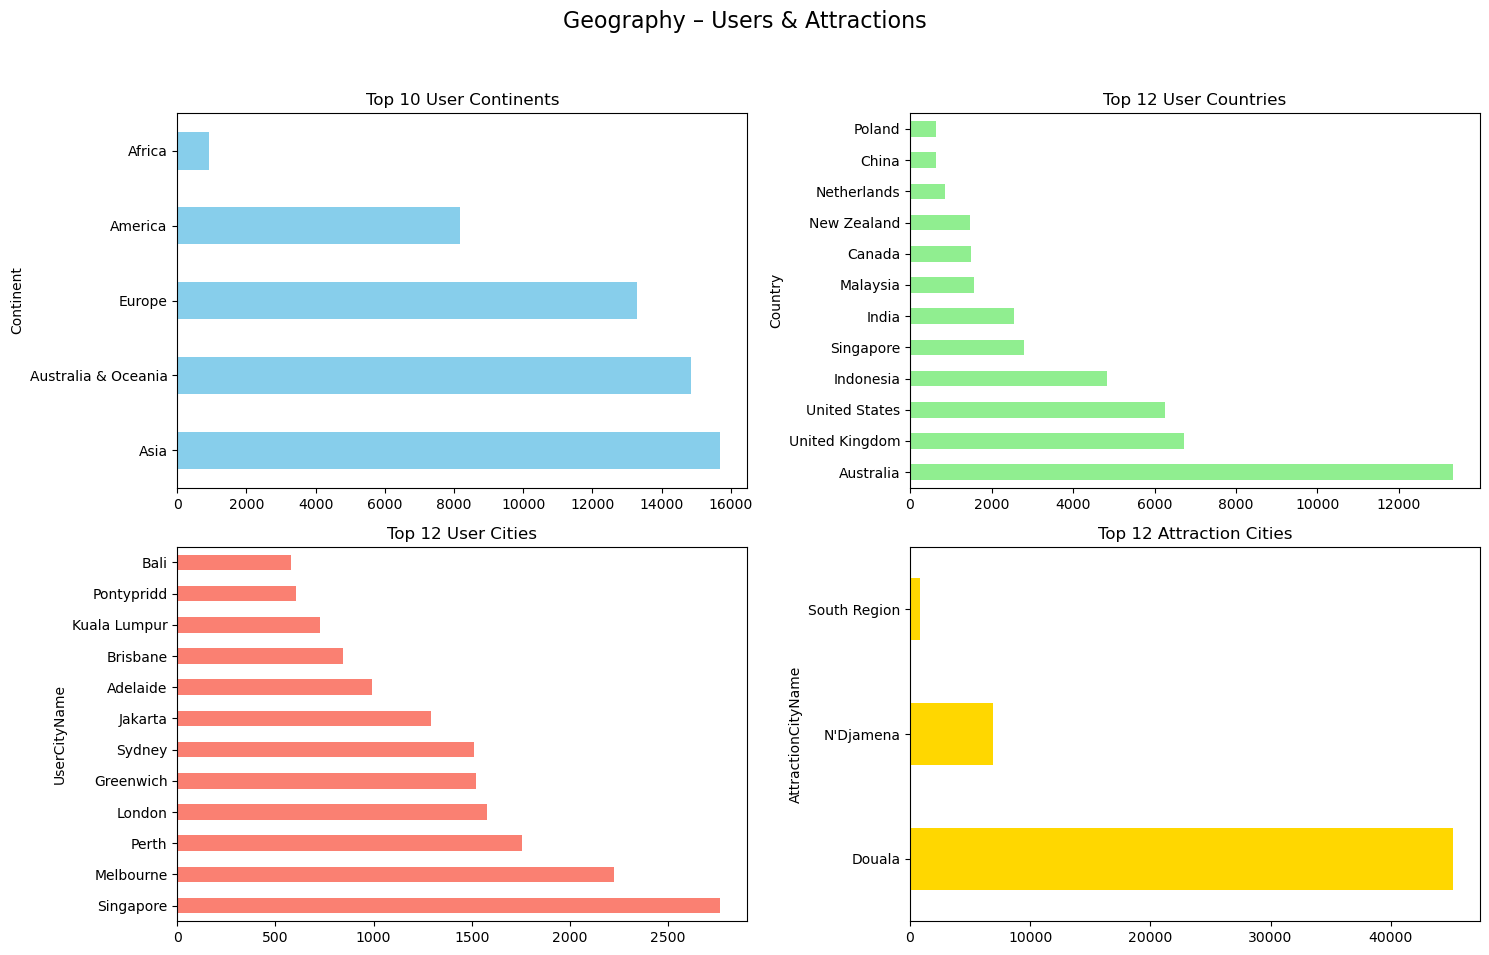

In [53]:
# EDA 5 – Geography (safe version after merges)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Geography – Users & Attractions', fontsize=16)

# Continent
if 'Continent' in master.columns:
    master['Continent'].value_counts().head(10).plot.barh(ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Top 10 User Continents')
else:
    axes[0,0].text(0.5, 0.5, 'No Continent', ha='center', va='center')

# Country
if 'Country' in master.columns:
    master['Country'].value_counts().head(12).plot.barh(ax=axes[0,1], color='lightgreen')
    axes[0,1].set_title('Top 12 User Countries')
else:
    axes[0,1].text(0.5, 0.5, 'No Country', ha='center', va='center')

# User City
if 'UserCityName' in master.columns:
    master['UserCityName'].value_counts().head(12).plot.barh(ax=axes[1,0], color='salmon')
    axes[1,0].set_title('Top 12 User Cities')
else:
    axes[1,0].text(0.5, 0.5, 'No UserCityName', ha='center', va='center')

# Attraction City
if 'AttractionCityName' in master.columns:
    master['AttractionCityName'].value_counts().head(12).plot.barh(ax=axes[1,1], color='gold')
    axes[1,1].set_title('Top 12 Attraction Cities')
else:
    axes[1,1].text(0.5, 0.5, 'No AttractionCityName', ha='center', va='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eda_05_geography_now_with_names.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
master.to_parquet("master_after_eda_checkpoint.parquet", index=False)
print("EDA checkpoint saved")

EDA checkpoint saved


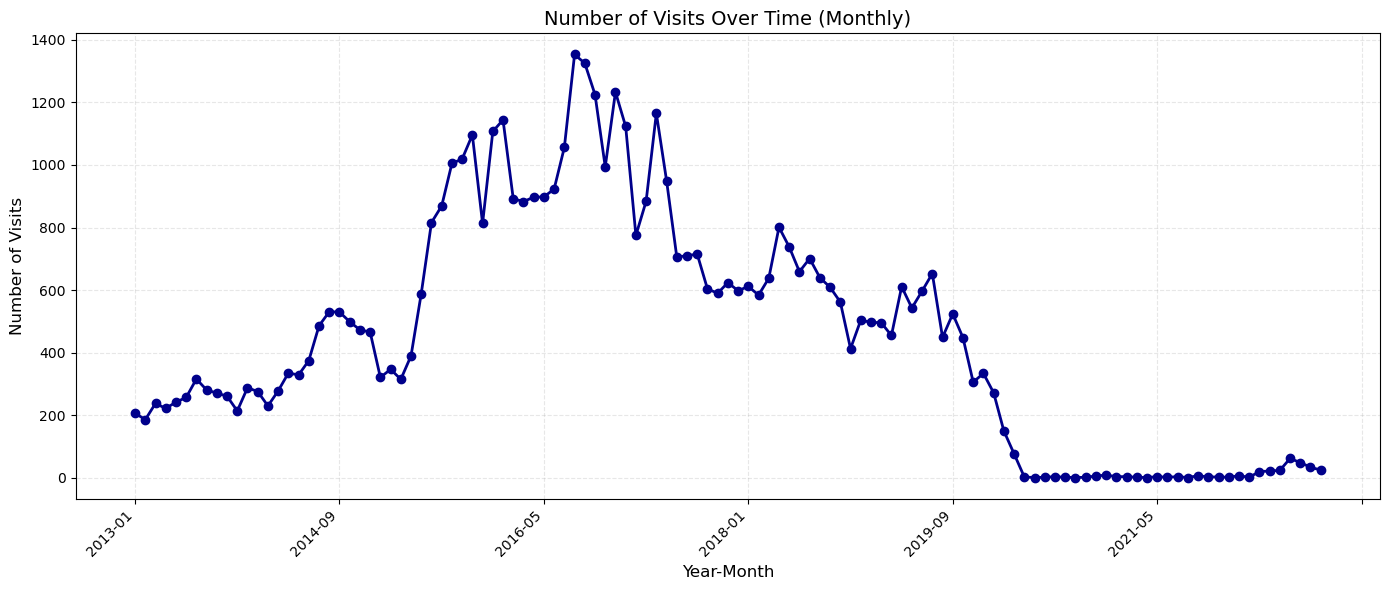

In [57]:
# EDA 6 – Visits over time (monthly trend)
if 'VisitYearMonth' in master.columns:
    plt.figure(figsize=(14, 6))
    monthly_visits = master.groupby('VisitYearMonth').size()
    monthly_visits.plot(kind='line', marker='o', color='darkblue', linewidth=2)
    plt.title('Number of Visits Over Time (Monthly)', fontsize=14)
    plt.xlabel('Year-Month', fontsize=12)
    plt.ylabel('Number of Visits', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('eda_09_visits_over_time_monthly.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("VisitYearMonth column not found – skipping time trend")

<Figure size 1200x700 with 0 Axes>

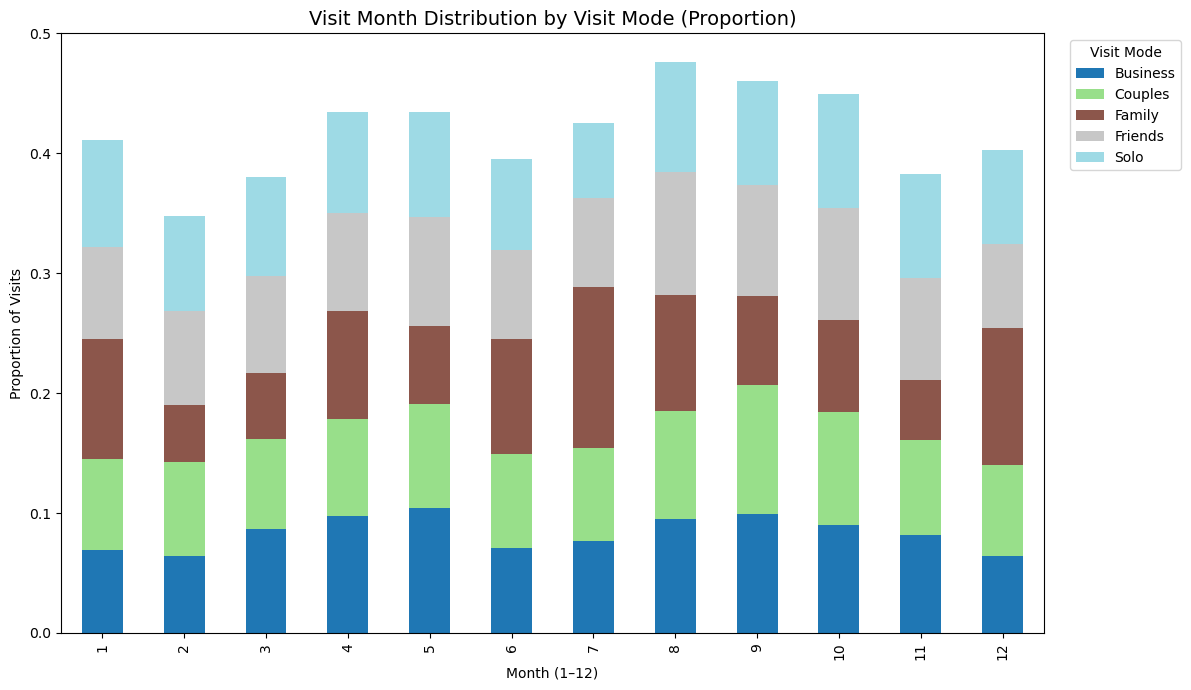

In [58]:
# EDA 7 – Visit Month distribution by Visit Mode (seasonality)
plt.figure(figsize=(12, 7))
pd.crosstab(master['VisitMonth'], master['VisitMode_Name'], normalize='columns').plot(
    kind='bar', stacked=True, colormap='tab20', figsize=(12,7)
)
plt.title('Visit Month Distribution by Visit Mode (Proportion)', fontsize=14)
plt.xlabel('Month (1–12)')
plt.ylabel('Proportion of Visits')
plt.legend(title='Visit Mode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_10_month_by_mode_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

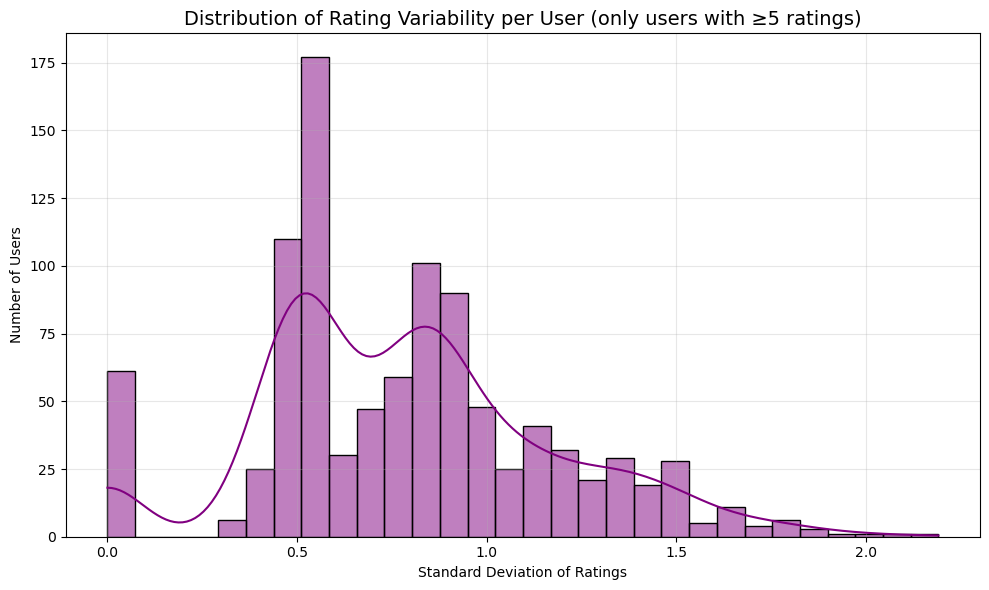

Users with ≥5 ratings: 982
Average rating variability (std): 0.784


In [59]:
# EDA 8 – How consistent are users in their ratings? (rating std dev per user)
user_rating_stats = master.groupby('UserId')['Rating'].agg(['mean', 'std', 'count'])
user_rating_stats = user_rating_stats[user_rating_stats['count'] >= 5]  # at least 5 ratings

plt.figure(figsize=(10, 6))
sns.histplot(user_rating_stats['std'], bins=30, kde=True, color='purple')
plt.title('Distribution of Rating Variability per User (only users with ≥5 ratings)', fontsize=14)
plt.xlabel('Standard Deviation of Ratings')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_11_user_rating_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Users with ≥5 ratings: {len(user_rating_stats)}")
print(f"Average rating variability (std): {user_rating_stats['std'].mean():.3f}")

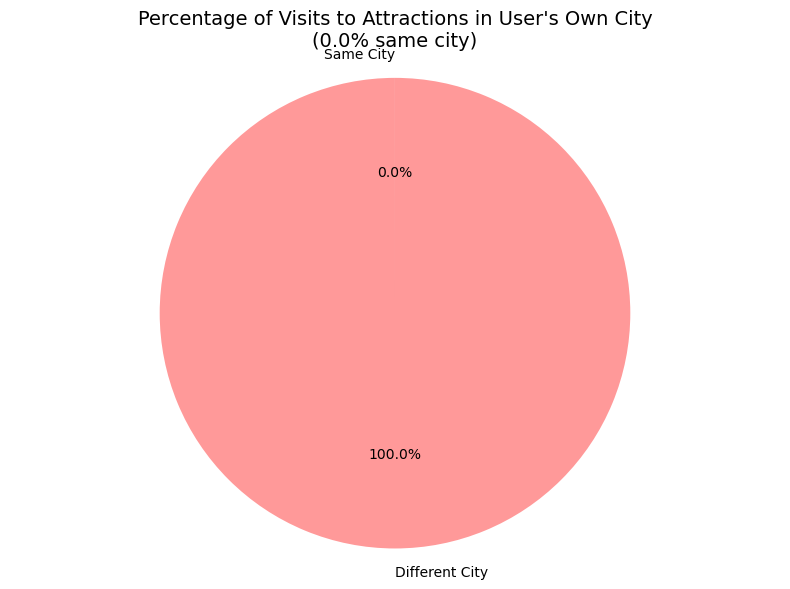

In [60]:
# EDA 9 – Do users visit attractions in their own city more often?
if 'UserCityName' in master.columns and 'AttractionCityName' in master.columns:
    master['SameCityVisit'] = master['UserCityName'] == master['AttractionCityName']
    
    same_city_pct = master['SameCityVisit'].mean() * 100
    plt.figure(figsize=(8, 6))
    plt.pie([same_city_pct, 100 - same_city_pct], 
            labels=['Same City', 'Different City'], 
            autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
    plt.title(f'Percentage of Visits to Attractions in User\'s Own City\n({same_city_pct:.1f}% same city)', fontsize=14)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig('eda_12_same_city_visits_pie.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("UserCityName or AttractionCityName not available – skipping same-city analysis")

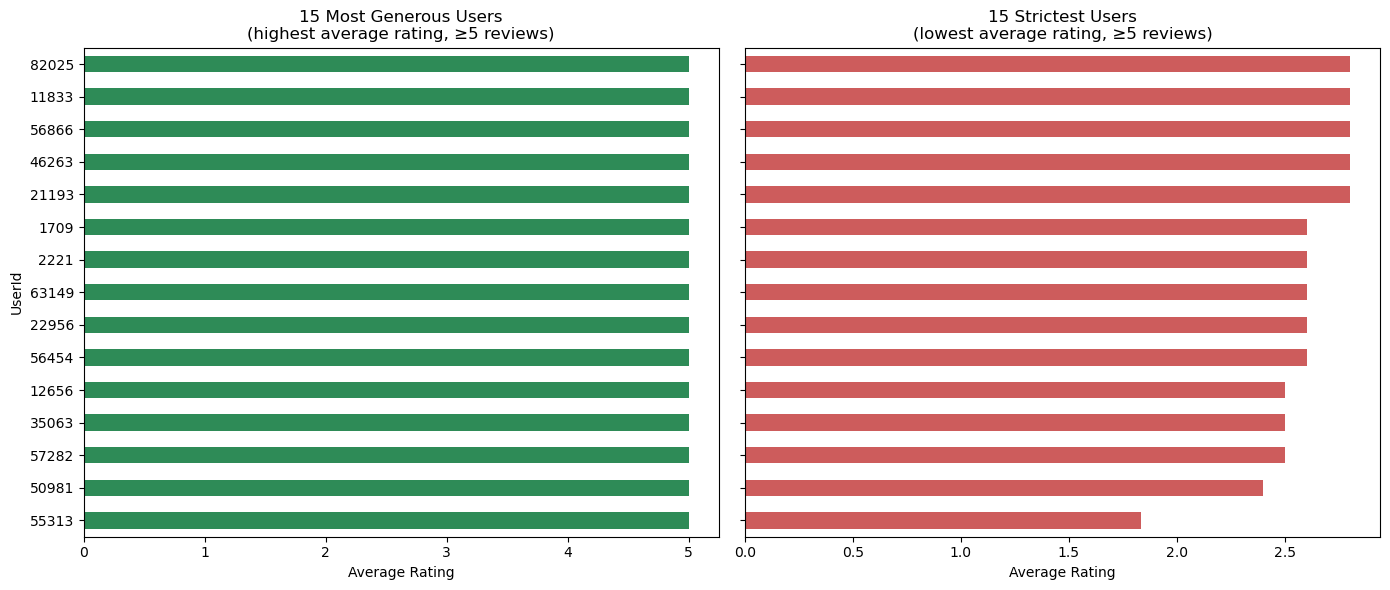

Most generous avg rating: 5.00
Strictest avg rating:     1.83


In [61]:
# EDA 10 – User Rating Strictness / Generosity (how generous or harsh users are)
# Only users with at least 5 ratings

user_stats = master.groupby('UserId')['Rating'].agg(['mean', 'count', 'std'])
generous_users = user_stats[user_stats['count'] >= 5].sort_values('mean', ascending=False).head(15)
strict_users   = user_stats[user_stats['count'] >= 5].sort_values('mean').head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

generous_users['mean'].plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('15 Most Generous Users\n(highest average rating, ≥5 reviews)')
axes[0].set_xlabel('Average Rating')

strict_users['mean'].plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('15 Strictest Users\n(lowest average rating, ≥5 reviews)')
axes[1].set_xlabel('Average Rating')

plt.tight_layout()
plt.savefig('eda_13_user_generosity_vs_strictness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most generous avg rating: {generous_users['mean'].max():.2f}")
print(f"Strictest avg rating:     {strict_users['mean'].min():.2f}")

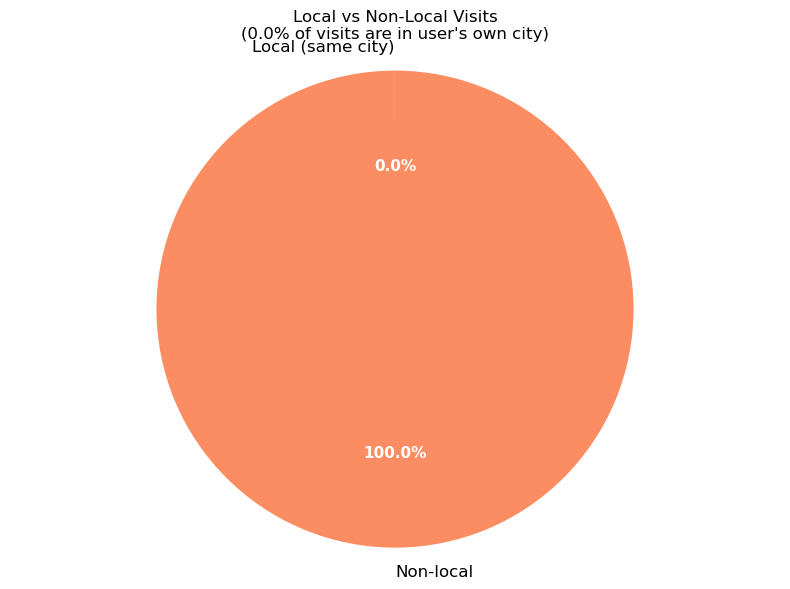

Top 10 non-local travel pairs (user city → attraction city):
UserCityName  AttractionCityName
Melbourne     Douala                2187
Singapore     Douala                1817
Perth         Douala                1720
Greenwich     N'Djamena             1516
London        Douala                1513
Sydney        Douala                1496
Adelaide      Douala                 974
Singapore     N'Djamena              903
Brisbane      Douala                 822
Jakarta       Douala                 724
dtype: int64


In [62]:
# EDA 11 – Distance between user home city and attraction city (geographical preference)
# Only if we have both city names

if 'UserCityName' in master.columns and 'AttractionCityName' in master.columns:
    master['IsLocalVisit'] = master['UserCityName'] == master['AttractionCityName']
    
    local_pct = master['IsLocalVisit'].mean() * 100
    
    fig, ax = plt.subplots(figsize=(8, 6))
    wedges, texts, autotexts = ax.pie(
        [local_pct, 100 - local_pct],
        labels=['Local (same city)', 'Non-local'],
        autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62'],
        startangle=90,
        textprops={'fontsize': 12}
    )
    
    plt.setp(autotexts, size=11, weight="bold", color="white")
    ax.set_title(f"Local vs Non-Local Visits\n({local_pct:.1f}% of visits are in user's own city)")
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig('eda_14_local_vs_nonlocal_visits_pie.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Extra: top 10 cities where people travel from/to
    travel_flow = master[~master['IsLocalVisit']].groupby(['UserCityName', 'AttractionCityName']).size().nlargest(10)
    print("Top 10 non-local travel pairs (user city → attraction city):")
    print(travel_flow)
else:
    print("Cannot calculate local/non-local because city name columns are missing")

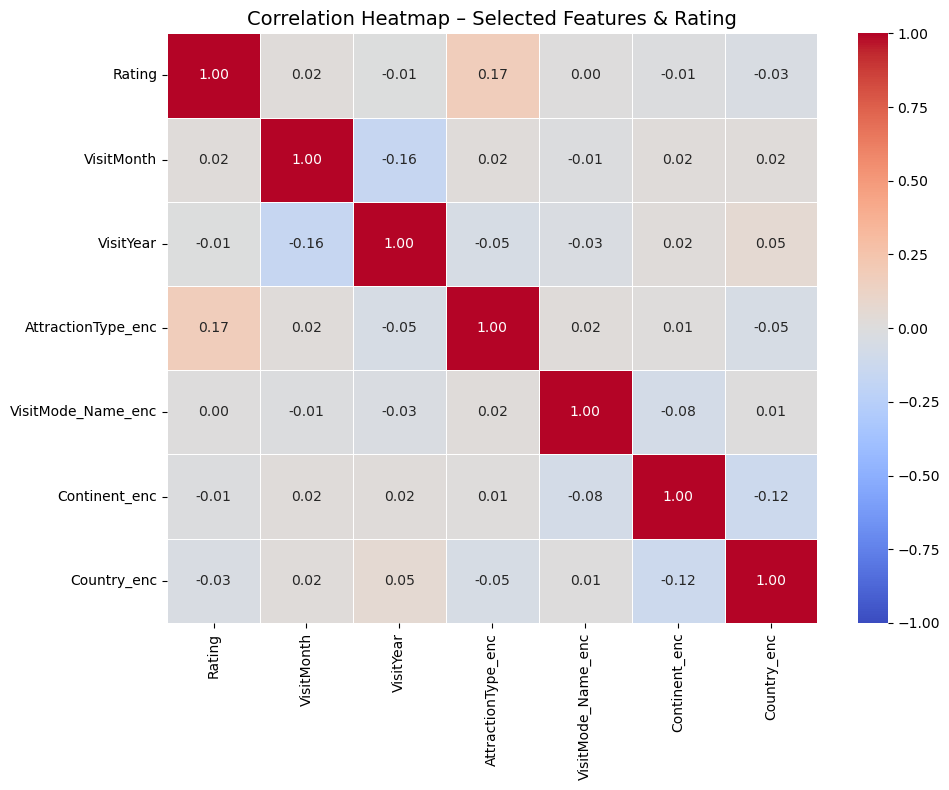

In [63]:
# EDA 12 – Correlation heatmap (numerical + encoded categorical features)
# Simple version – pick important columns

from sklearn.preprocessing import LabelEncoder

# Create temporary encoded columns for correlation
le = LabelEncoder()
corr_df = master.copy()

for col in ['AttractionType', 'VisitMode_Name', 'Continent', 'Country']:
    if col in corr_df.columns:
        corr_df[f'{col}_enc'] = le.fit_transform(corr_df[col].astype(str).fillna('Unknown'))

# Select columns for correlation
corr_columns = ['Rating', 'VisitMonth', 'VisitYear']
for col in corr_df.columns:
    if '_enc' in col or col in ['UserAvgRating']:
        corr_columns.append(col)

corr_matrix = corr_df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1,
    center=0
)
plt.title('Correlation Heatmap – Selected Features & Rating', fontsize=14)
plt.tight_layout()
plt.savefig('eda_15_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
import os

# Create folder inside your project directory
plots_folder = "eda_plots"

if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)
    print(f"Created folder: {os.path.abspath(plots_folder)}")
else:
    print(f"Folder already exists: {os.path.abspath(plots_folder)}")

Created folder: C:\Users\NARKEES SALEEM\eda_plots


In [65]:
# Batch save – move or copy your saved plots into the folder
import shutil
import glob

# Find all .png files in current directory (that you saved earlier)
png_files = glob.glob("*.png")

for file in png_files:
    if file.startswith("eda_"):  # only your eda plots
        dest = os.path.join(plots_folder, file)
        shutil.move(file, dest)   # or use shutil.copy(file, dest) if you want to keep original
        print(f"Moved: {file} → {dest}")

print(f"\nAll EDA plots moved to: {os.path.abspath(plots_folder)}")
print(f"Total plots moved: {len(glob.glob(os.path.join(plots_folder, '*.png')))}")

Moved: eda_01_rating_distribution.png → eda_plots\eda_01_rating_distribution.png
Moved: eda_02_ratings_by_visit_mode.png → eda_plots\eda_02_ratings_by_visit_mode.png
Moved: eda_02_ratings_by_visit_mode_clean.png → eda_plots\eda_02_ratings_by_visit_mode_clean.png
Moved: eda_02_ratings_by_visit_mode_fixed.png → eda_plots\eda_02_ratings_by_visit_mode_fixed.png
Moved: eda_03_top_rated_attractions.png → eda_plots\eda_03_top_rated_attractions.png
Moved: eda_04_attraction_types_popularity_vs_rating.png → eda_plots\eda_04_attraction_types_popularity_vs_rating.png
Moved: eda_05_geography_now_with_names.png → eda_plots\eda_05_geography_now_with_names.png
Moved: eda_05_user_geography_updated.png → eda_plots\eda_05_user_geography_updated.png
Moved: eda_06_ratings_by_continent.png → eda_plots\eda_06_ratings_by_continent.png
Moved: eda_07_avg_rating_by_type.png → eda_plots\eda_07_avg_rating_by_type.png
Moved: eda_09_visits_over_time_monthly.png → eda_plots\eda_09_visits_over_time_monthly.png
Moved: 

In [66]:
plt.figure(figsize=(10, 6))
# your plot code here ...
plt.tight_layout()
plt.savefig(f"{plots_folder}/eda_XX_name_of_plot.png", dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

In [67]:
# ────────────────────────────────────────────────
# Cell 1: Regression – Prepare Features & Target
# ────────────────────────────────────────────────

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Target
y = master['Rating']

# Features – select useful ones (avoid leakage like AttractionAvgRating if you created it earlier)
feature_cols = [
    'VisitMonth', 'VisitYear', 
    'VisitMode_Name', 'AttractionType', 
    'Continent', 'Country', 
    'UserCityName', 'AttractionCityName',
    # add more if you have: 'UserAvgRating', 'VisitCount' etc.
]

# Create X – only existing columns
available_features = [c for c in feature_cols if c in master.columns]
X = master[available_features].copy()

print(f"Using {len(available_features)} features:")
print(available_features)
print(f"X shape: {X.shape}, y shape: {y.shape}")

Using 8 features:
['VisitMonth', 'VisitYear', 'VisitMode_Name', 'AttractionType', 'Continent', 'Country', 'UserCityName', 'AttractionCityName']
X shape: (52930, 8), y shape: (52930,)


In [68]:
# Cell 2: Encode Categorical Columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str).fillna('Unknown'))
    encoders[col] = le

print("Categorical columns encoded.")

Categorical columns encoded.


In [69]:
# Cell 3: Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Train size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")

Train size: 42,344 rows
Test size:  10,586 rows


In [70]:
# Cell 4: Train Baseline – Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict on test
y_pred_rf = rf.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Results:
RMSE: 0.9214
MAE:  0.7185
R²:   0.0986


In [72]:
# Cell 6: Simple Prediction Example (for testing / demo)
# Pick one real row from test set
example_idx = 0
example_row = X_test.iloc[[example_idx]]
true_rating = y_test.iloc[example_idx]

pred_rating = rf.predict(example_row)[0]

print("Example Prediction:")
print(f"Features:\n{example_row.to_string()}")
print(f"True Rating:   {true_rating:.1f}")
print(f"Predicted Rating: {pred_rating:.2f}")

Example Prediction:
Features:
       VisitMonth  VisitYear  VisitMode_Name  AttractionType  Continent  Country  UserCityName  AttractionCityName
32962          10       2018               1              10          4      144          3986                   0
True Rating:   5.0
Predicted Rating: 4.17


In [73]:
print("Random Forest Regression Metrics on Test Set:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")


Random Forest Regression Metrics on Test Set:
RMSE: 0.9214
MAE:  0.7185
R²:   0.0986


In [75]:
! pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 321.7 kB/s eta 0:03:43
   ---------------------------------------- 0.5/72.0 MB 321.7 kB/s eta 0:03:43
   ---------------------------------------- 0.8/72.0 MB 363.5 kB/s eta 0:03:16
   ---------------------------------------- 0.8/72.0 MB 363.5 k

In [76]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")

XGBoost Results:
RMSE: 0.9196
MAE:  0.7176
R²:   0.1020


In [79]:
import os

# Create the 'models' folder if it doesn't exist
models_folder = "models"

if not os.path.exists(models_folder):
    os.makedirs(models_folder)
    print(f"Created folder: {os.path.abspath(models_folder)}")
else:
    print(f"Folder already exists: {os.path.abspath(models_folder)}")

Created folder: C:\Users\NARKEES SALEEM\models


In [80]:
import joblib

joblib.dump(rf, 'models/rf_rating_predictor.pkl')

# If XGBoost is installed and trained
# joblib.dump(xgb, 'models/xgb_rating_predictor.pkl')

print("Model(s) saved successfully in 'models/' folder")
print("Files created:")
print(os.listdir('models'))

Model(s) saved successfully in 'models/' folder
Files created:
['rf_rating_predictor.pkl']


In [81]:
import os

print("Files in 'models/' folder:")
print(os.listdir('models'))

Files in 'models/' folder:
['rf_rating_predictor.pkl']


In [3]:
import pandas as pd
import os

# Your data folder path – change if different
DATA_FOLDER = r"C:\Users\NARKEES SALEEM\tourism_project\data"

# Reload main tables
df_trans = pd.read_excel(f"{DATA_FOLDER}/Transaction.xlsx")
df_user  = pd.read_excel(f"{DATA_FOLDER}/User.xlsx")
df_item  = pd.read_excel(f"{DATA_FOLDER}/Item.xlsx")
df_type  = pd.read_excel(f"{DATA_FOLDER}/Type.xlsx")
df_mode  = pd.read_excel(f"{DATA_FOLDER}/Mode.xlsx")
df_city  = pd.read_excel(f"{DATA_FOLDER}/City.xlsx")
df_continent = pd.read_excel(f"{DATA_FOLDER}/Continent.xlsx")
df_country   = pd.read_excel(f"{DATA_FOLDER}/Country.xlsx")

print("Tables reloaded")

Tables reloaded


In [4]:
# Re-create master with correct merges & renames
master = (
    df_trans
    .merge(df_user, on='UserId', how='left')
    .merge(df_item, on='AttractionId', how='left')
    .merge(df_type, on='AttractionTypeId', how='left')
    .merge(df_mode, left_on='VisitMode', right_on='VisitModeId', how='left')
    .merge(df_city, left_on='AttractionCityId', right_on='CityId', how='left', suffixes=('', '_city'))
)

# Rename mode columns
master = master.rename(columns={
    'VisitMode_x': 'VisitModeId_Num',
    'VisitMode_y': 'VisitMode_Name'
})

# Create year-month if needed
if 'VisitYear' in master.columns and 'VisitMonth' in master.columns:
    master['VisitYearMonth'] = master['VisitYear'].astype(str) + '-' + master['VisitMonth'].astype(str).str.zfill(2)

print("Master recreated")
print("Shape:", master.shape)
print("Columns:", master.columns.tolist())

Master recreated
Shape: (52930, 22)
Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId_Num', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'VisitModeId', 'VisitMode_Name', 'CityId_city', 'CityName', 'CountryId_city', 'VisitYearMonth']


In [5]:
# Target: VisitMode_Name (categorical)
master_class = master.dropna(subset=['VisitMode_Name']).copy()
y_class = master_class['VisitMode_Name']

=== Classification: Predict Visit Mode ===
Master shape: (52930, 22)

Using 10 features: ['Rating', 'VisitMonth', 'VisitYear', 'AttractionType', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId']
X shape: (52930, 10)  |  y shape: (52930,)

Class distribution (%):
VisitMode_Name
Couples     40.8
Family      28.7
Friends     20.7
Solo         8.5
Business     1.2
Name: proportion, dtype: float64

Encoded 5 classes:
['Business' 'Couples' 'Family' 'Friends' 'Solo']

Train: 42,344 rows | Test: 10,586 rows

Random Forest Classifier Results:
Accuracy:          0.4045  (40.4%)
F1-score (weighted): 0.4190

Detailed Classification Report:
              precision    recall  f1-score   support

    Business       0.07      0.46      0.12       125
     Couples       0.52      0.53      0.53      4324
      Family       0.54      0.37      0.44      3043
     Friends       0.34      0.23      0.27      2189
        Solo       0.16      0.31      0.22       905

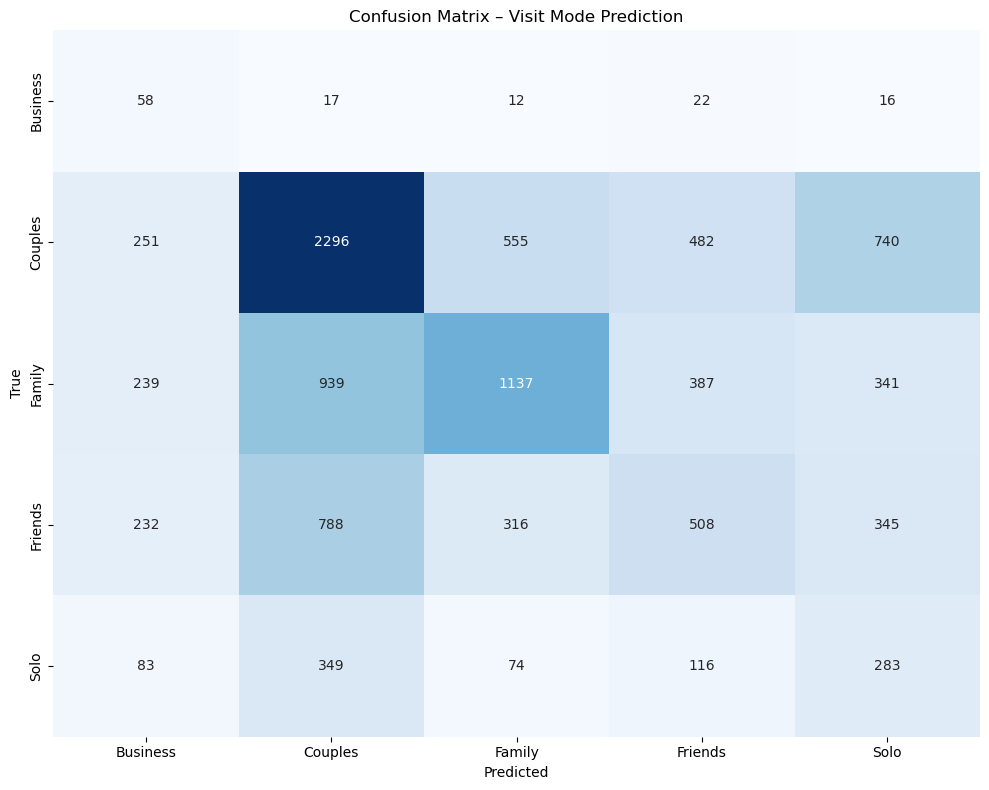

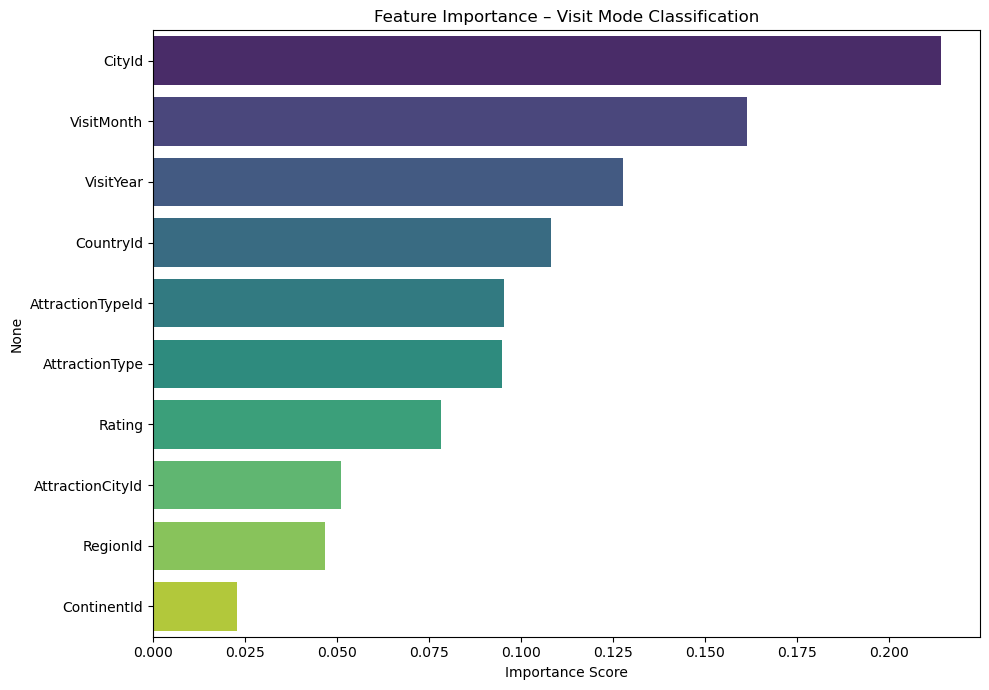


Classification complete!
Model & encoder saved in 'models/' folder
Files now: ['rf_rating_predictor.pkl', 'rf_visitmode_classifier.pkl', 'visitmode_label_encoder.pkl']


In [7]:
# ────────────────────────────────────────────────
# SINGLE CELL: CLASSIFICATION – Predict VisitMode_Name
# Run this after master is loaded and ready
# ────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import os

print("=== Classification: Predict Visit Mode ===")
print("Master shape:", master.shape)

# 1. Prepare data
df_clf = master.dropna(subset=['VisitMode_Name']).copy()
y = df_clf['VisitMode_Name']

feature_cols = [
    'Rating', 'VisitMonth', 'VisitYear',
    'AttractionType', 'ContinentId', 'RegionId', 'CountryId', 'CityId',
    'AttractionCityId', 'AttractionTypeId'
]

available_features = [c for c in feature_cols if c in df_clf.columns]
X = df_clf[available_features].copy()

print(f"\nUsing {len(available_features)} features: {available_features}")
print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print("\nClass distribution (%):")
print(y.value_counts(normalize=True).round(3) * 100)

# 2. Encode categorical columns + target
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str).fillna('Unknown'))

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print(f"\nEncoded {len(le_y.classes_)} classes:")
print(le_y.classes_)

# 3. Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

# 4. Train Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_clf.fit(X_train, y_train)

# Predict
y_pred = rf_clf.predict(X_test)

# 5. Metrics
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("\nRandom Forest Classifier Results:")
print(f"Accuracy:          {acc:.4f}  ({acc*100:.1f}%)")
print(f"F1-score (weighted): {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

# 6. Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_y.classes_,
    yticklabels=le_y.classes_,
    cbar=False
)
plt.title('Confusion Matrix – Visit Mode Prediction')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance – Visit Mode Classification (warning-free)
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,          # ← fixes the warning
    palette='viridis',
    dodge=False,
    legend=False                    # ← hides duplicate legend
)
plt.title('Feature Importance – Visit Mode Classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('classification_feature_importance_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Save model + encoder
os.makedirs('models', exist_ok=True)
joblib.dump(rf_clf, 'models/rf_visitmode_classifier.pkl')
joblib.dump(le_y, 'models/visitmode_label_encoder.pkl')

print("\nClassification complete!")
print("Model & encoder saved in 'models/' folder")
print("Files now:", os.listdir('models'))